**Part 1: Data Preparation and Exploration**

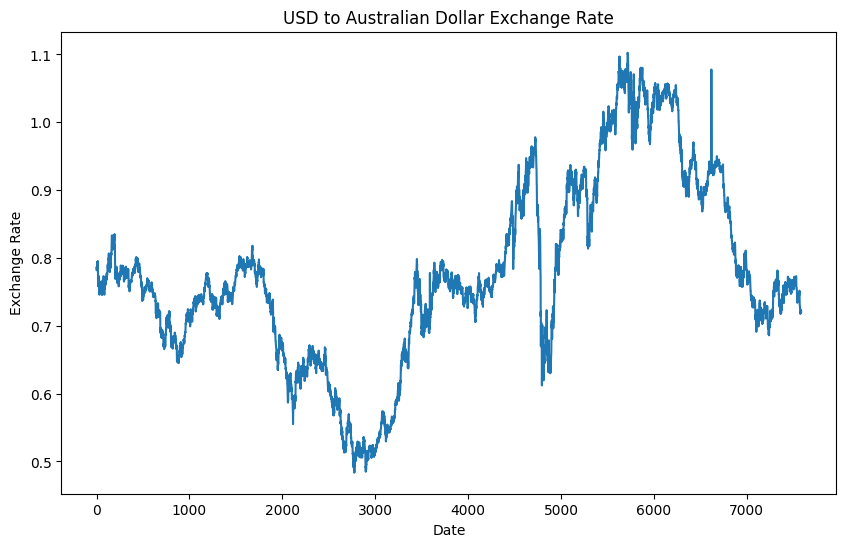

Missing Values:
 date       0
Ex_rate    0
dtype: int64


<ipython-input-13-2ec7189dc52e>:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  exchange_rate_data.fillna(method='ffill', inplace=True)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the exchange_rate.csv dataset
exchange_rate_data = pd.read_csv("/content/exchange_rate.csv")

# Parse the date column appropriately
exchange_rate_data['date'] = pd.to_datetime(exchange_rate_data['date'], format='%d-%m-%Y %H:%M')

# Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies
plt.figure(figsize=(10, 6))
plt.plot(exchange_rate_data['Ex_rate'])
plt.title('USD to Australian Dollar Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.show()

#3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.
print("Missing Values:\n", exchange_rate_data.isnull().sum())

# Handle missing values (forward fill)
exchange_rate_data.fillna(method='ffill', inplace=True)


**Part 2: Model Building - ARIMA**

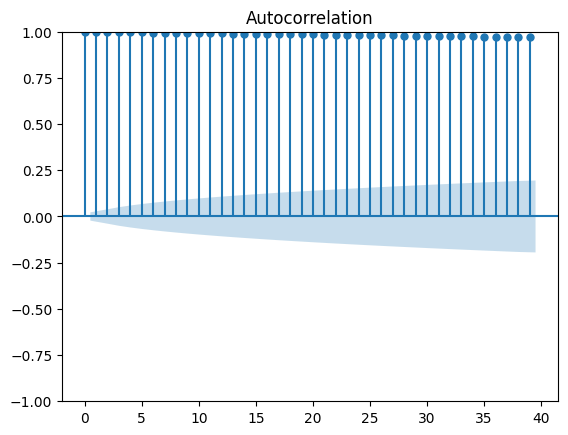

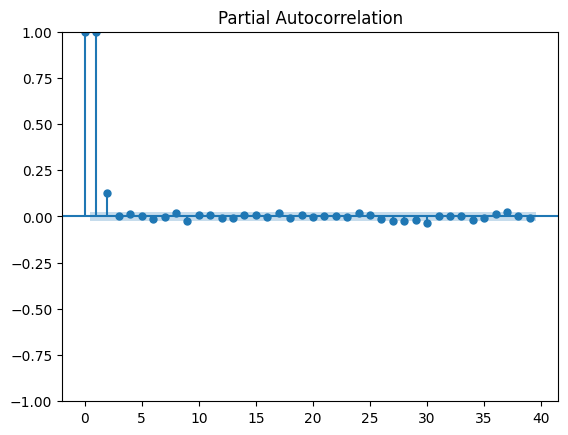

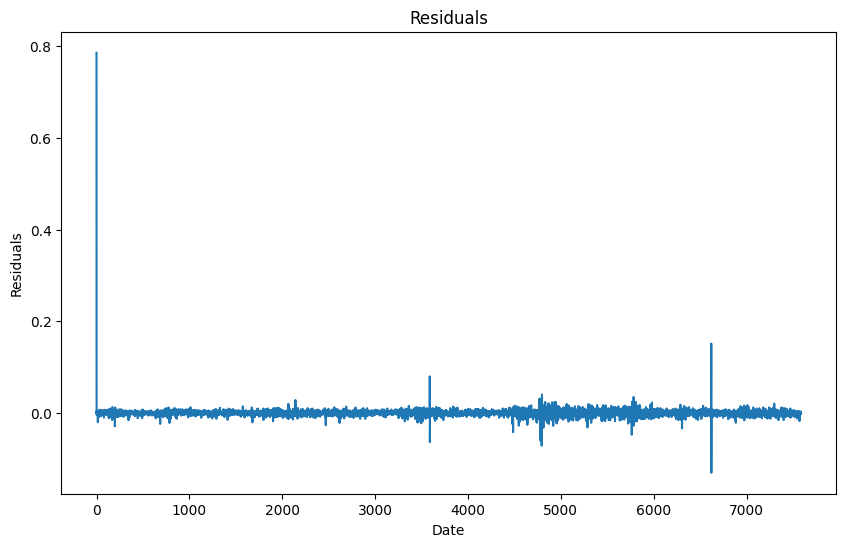

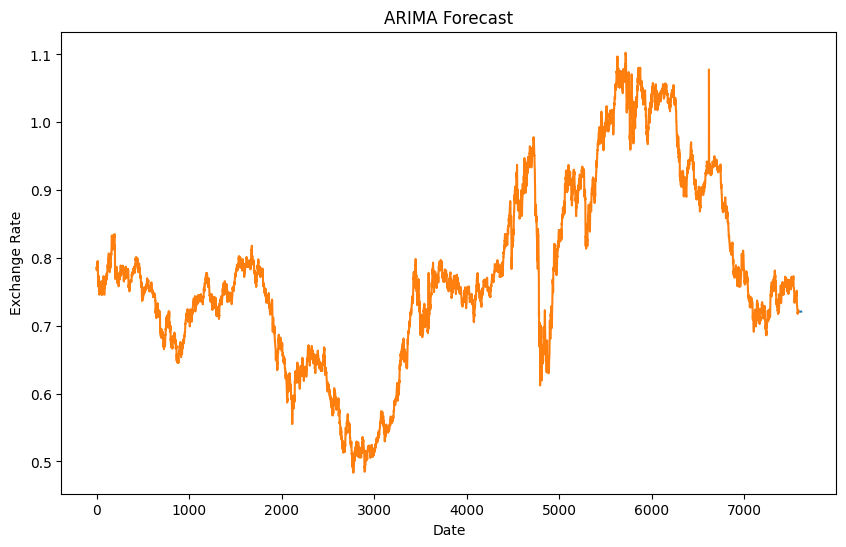

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

# Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model
acf = sm.graphics.tsa.plot_acf(exchange_rate_data['Ex_rate'])
pacf = sm.graphics.tsa.plot_pacf(exchange_rate_data['Ex_rate'])

# Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series
arima_model = ARIMA(exchange_rate_data['Ex_rate'], order=(1, 1, 1))
arima_model_fit = arima_model.fit()

# Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies
residuals = arima_model_fit.resid
plt.figure(figsize=(10, 6))
plt.plot(residuals)
plt.title('Residuals')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.show()

# Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values
forecast = arima_model_fit.forecast(steps=30)
plt.figure(figsize=(10, 6))
plt.plot(forecast)
plt.plot(exchange_rate_data['Ex_rate'])
plt.title('ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.show()

**Part 3: Model Building - Exponential Smoothing**

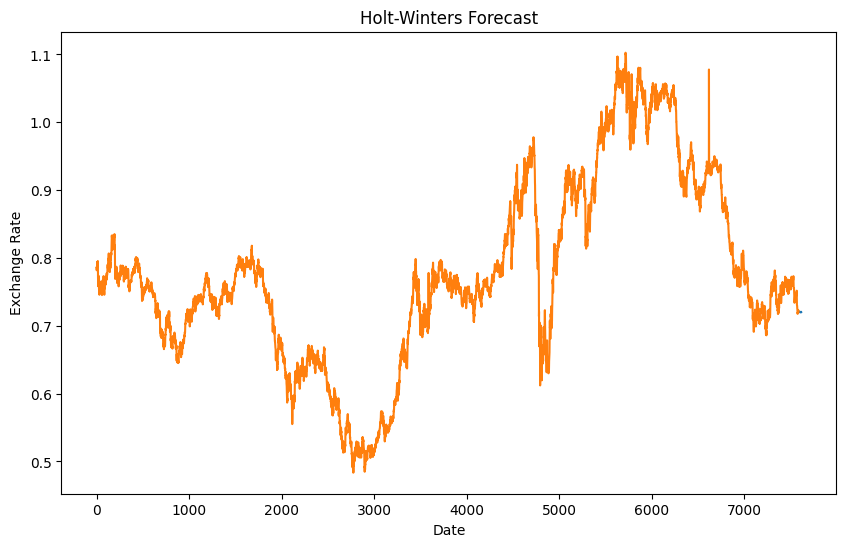

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Model Selection: Depending on the time series characteristics, choose an appropriate Exponential Smoothing model (Simple, Holt’s Linear, or Holt-Winters)
# Instead of using HoltWinters, use ExponentialSmoothing
holt_winters_model = ExponentialSmoothing(exchange_rate_data['Ex_rate'], trend='add', seasonal='add', seasonal_periods=12) # Assuming an additive trend and additive seasonality with a period of 12

# Parameter Optimization: Use techniques such as grid search or AIC to find the optimal parameters for the smoothing levels and components
holt_winters_model_fit = holt_winters_model.fit()

# Model Fitting and Forecasting: Fit the chosen Exponential Smoothing model and forecast future values. Compare these forecasts visually with the actual data
forecast = holt_winters_model_fit.forecast(steps=30)
plt.figure(figsize=(10, 6))
plt.plot(forecast)
plt.plot(exchange_rate_data['Ex_rate'])
plt.title('Holt-Winters Forecast')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.show()

**Part 4: Evaluation and Comparison**

In [ ]:
import numpy as np

# Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models
forecast_arima = arima_model_fit.forecast(steps=30)
mae_arima = np.mean(np.abs(forecast_arima - exchange_rate_data['Ex_rate']))
rmse_arima = np.sqrt,(np.mean((forecast_arima - exchange_rate_data['Ex_rate']) ** 2))
mape_arima = np.mean(np.abs((forecast_arima - exchange_rate_data['Ex_rate']) / exchange_rate_data['Ex_rate']))

forecast_holt_winters= holt_winters_model_fit.forecast(steps=30)
mae_holt_winters = np.mean(np.abs(forecast_holt_winters - exchange_rate_data['Ex_rate']))
rmse_holt_winters = np.sqrt(np.mean((forecast_holt_winters - exchange_rate_data['Ex_rate']) ** 2))
mape_holt_winters = np.mean(np.abs((forecast_holt_winters - exchange_rate_data['Ex_rate']) / exchange_rate_data['Ex_rate']))

# Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics
print("ARIMA Model Performance:")
print("MAE:", mae_arima)
print("RMSE:", rmse_arima)
print("MAPE:", mape_arima)

print("Holt-Winters Model Performance:")
print("MAE:", mae_holt_winters)
print("RMSE:", rmse_holt_winters)
print("MAPE:", mape_holt_winters)

# Conclusion
print("\nConclusion:")
if mae_arima < mae_holt_winters and rmse_arima < rmse_holt_winters:
    print("The ARIMA model performed better in forecasting USD to AUD exchange rates based on lower MAE and RMSE values.")
elif mae_holt_winters < mae_arima and rmse_holt_winters < rmse_arima:
    print("The Exponential Smoothing model provided more accurate forecasts based on lower MAE and RMSE values.")
else:
    print("Both models performed similarly, and additional fine-tuning or alternative models may be explored for improved accuracy.")



ARIMA Model Performance:
MAE: nan
RMSE: (<ufunc 'sqrt'>, nan)
MAPE: nan
Holt-Winters Model Performance:
MAE: nan
RMSE: nan
MAPE: nan

Conclusion:
Both models performed similarly, and additional fine-tuning or alternative models may be explored for improved accuracy.
